In [2]:
# mysql
# create table churn(
#     -> customer_id int primary key,
#     -> tenure_months int not null,
#     -> monthly_fee float not null,
#     -> total_usage_gb float not null,
#     -> support_calls int not null,
#     -> has_contract tinyint not null, #tinyint 이진분류 (약정 1:있음 0:없음)
#     -> churned tinyint not null
#     -> );

In [3]:
import pymysql

conn = pymysql.connect(
    host='localhost',
    user='user',
    password='1234',
    database='testdb',
    charset='utf8'
)

cursor = conn.cursor()
cursor.execute('select * from churn order by customer_id')
rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 2, 55.0, 40.0, 5, 0, 1)
(2, 3, 58.0, 45.0, 4, 0, 1)
(3, 1, 52.0, 35.0, 6, 0, 1)
(4, 4, 60.0, 50.0, 3, 0, 1)
(5, 5, 62.0, 55.0, 2, 0, 0)
(6, 6, 64.0, 60.0, 3, 0, 1)
(7, 7, 66.0, 65.0, 2, 0, 0)
(8, 3, 57.0, 42.0, 4, 0, 1)
(9, 8, 68.0, 70.0, 1, 0, 0)
(10, 2, 54.0, 38.0, 5, 0, 1)
(11, 4, 59.0, 48.0, 3, 0, 1)
(12, 6, 63.0, 58.0, 2, 0, 0)
(13, 1, 51.0, 30.0, 6, 0, 1)
(14, 5, 61.0, 54.0, 3, 0, 0)
(15, 3, 56.0, 44.0, 4, 0, 1)
(16, 12, 70.0, 110.0, 1, 1, 0)
(17, 18, 75.0, 140.0, 0, 1, 0)
(18, 24, 80.0, 160.0, 0, 1, 0)
(19, 36, 85.0, 180.0, 0, 1, 0)
(20, 48, 90.0, 200.0, 0, 1, 0)
(21, 10, 68.0, 95.0, 1, 1, 0)
(22, 14, 72.0, 105.0, 1, 1, 0)
(23, 20, 78.0, 150.0, 0, 1, 0)
(24, 30, 82.0, 170.0, 0, 1, 0)
(25, 8, 66.0, 85.0, 2, 1, 1)
(26, 16, 74.0, 120.0, 0, 1, 0)
(27, 22, 79.0, 155.0, 0, 1, 0)
(28, 28, 83.0, 175.0, 0, 1, 0)
(29, 6, 65.0, 75.0, 2, 1, 1)
(30, 12, 70.0, 100.0, 1, 1, 0)


In [4]:
import pandas as pd

df=pd.DataFrame(
    rows,
    columns=[
        'customer_id',
        'tenure_months',
        'monthly_fee',
        'total_usage_gb',
        'support_calls',
        'has_contract',
        'churned'
    ]
)
df.head()

,customer_id,tenure_months,monthly_fee,total_usage_gb,support_calls,has_contract,churned
0,1,2,55.0,40.0,5,0,1
1,2,3,58.0,45.0,4,0,1
2,3,1,52.0,35.0,6,0,1
3,4,4,60.0,50.0,3,0,1
4,5,5,62.0,55.0,2,0,0


In [5]:
df.to_csv('churn.csv', index=False)
print('저장 완료')

저장 완료


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('churn.csv')
df.head()

,customer_id,tenure_months,monthly_fee,total_usage_gb,support_calls,has_contract,churned
0,1,2,55.0,40.0,5,0,1
1,2,3,58.0,45.0,4,0,1
2,3,1,52.0,35.0,6,0,1
3,4,4,60.0,50.0,3,0,1
4,5,5,62.0,55.0,2,0,0


In [7]:
sns.set_theme(style='whitegrid')
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

In [8]:
churn_count = df['churned'].value_counts().sort_index()
print(churn_count)

churned
0    18
1    12
Name: count, dtype: int64


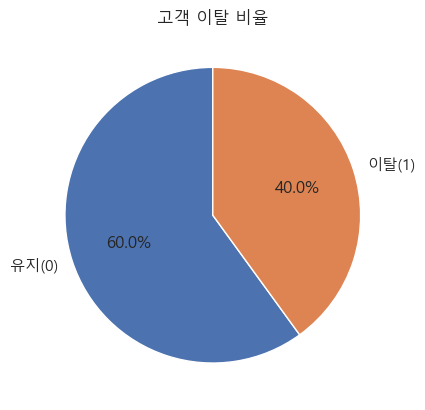

In [9]:
plt.figure()
plt.pie(
    churn_count,
    labels=['유지(0)', '이탈(1)'],
    autopct='%.1f%%',
    startangle=90
)
plt.title('고객 이탈 비율')
plt.show()

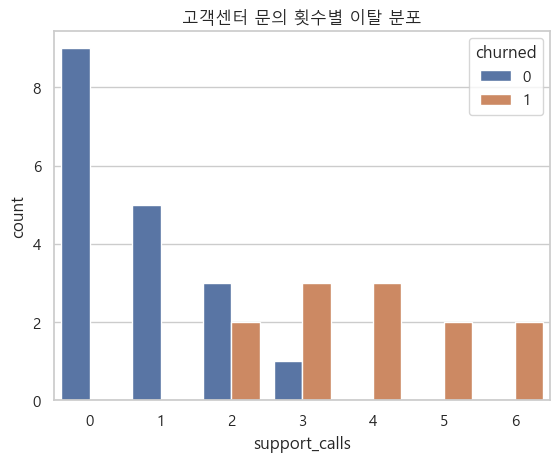

In [10]:
sns.countplot(
    x='support_calls',
    hue='churned',
    data=df
)
plt.title('고객센터 문의 횟수별 이탈 분포')
plt.show()

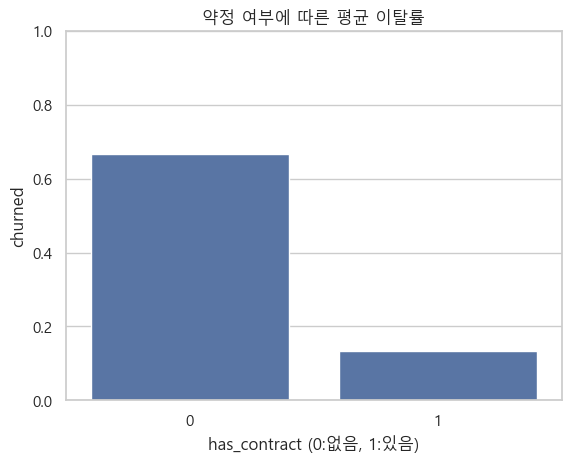

In [11]:
contract_churn = (
    df.groupby('has_contract')['churned']  #groupby(분류기준)[평균계산값].mean()
    .mean()
    .reset_index()
)

sns.barplot(
    x='has_contract',
    y='churned',
    data=contract_churn
)
plt.title('약정 여부에 따른 평균 이탈률')
plt.xlabel('has_contract (0:없음, 1:있음)')
plt.ylim(0,1) #y축 범위지정
plt.show()


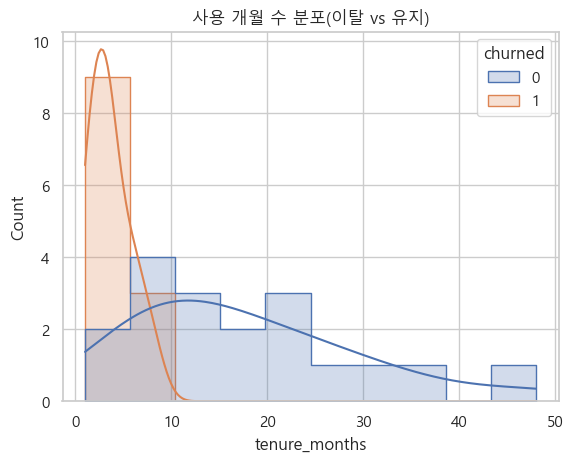

In [12]:
sns.histplot(
    data=df,
    x='tenure_months',
    hue='churned',
    bins=10,
    kde=True,
    element='step'
)
# handles, labels = ax.get_legend_handles_labels()
# new_labels = ["이탈", "유지"]
# ax.legend(handles, new_labels, title="이탈/유지")

plt.title('사용 개월 수 분포(이탈 vs 유지)')
plt.show()

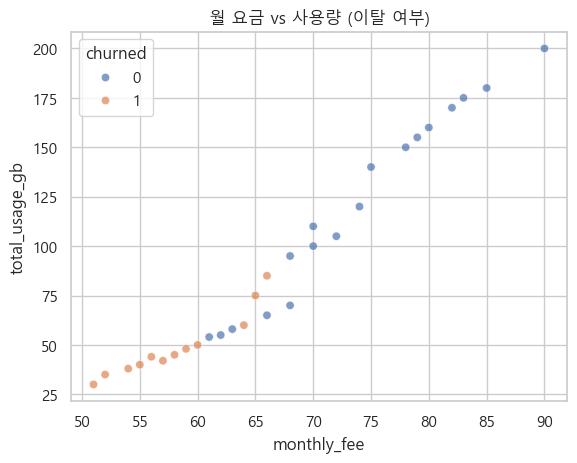

In [16]:
plt.figure()
sns.scatterplot(
    x='monthly_fee',
    y='total_usage_gb',
    hue='churned',
    data=df,
    alpha=0.7
)
plt.title('월 요금 vs 사용량 (이탈 여부)')
plt.show()

<Axes: >

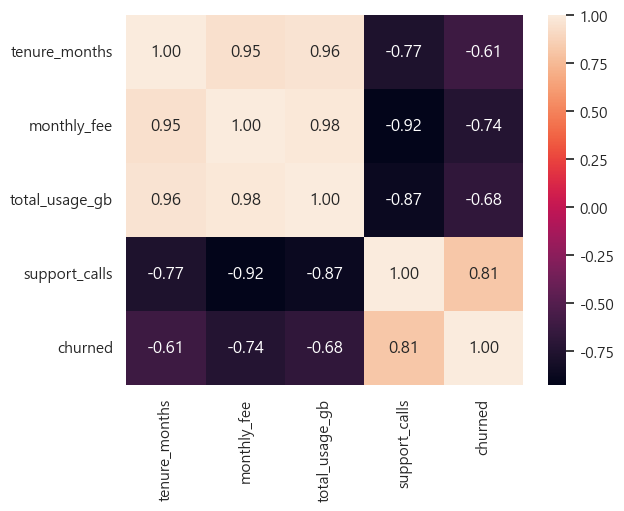

In [ ]:
corr = df[['tenure_months','monthly_fee','total_usage_gb','support_calls','churned']].corr()
plt.figure()
sns.heatmap(corr,annot=True,fmt='.2f')
plt.show()

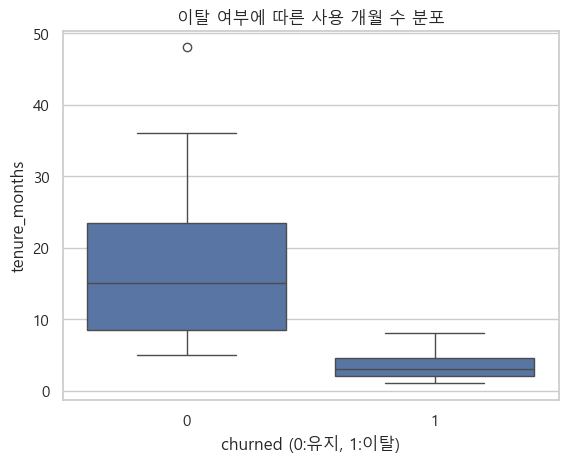

In [21]:
sns.boxplot(x='churned',y='tenure_months',data=df)
plt.title('이탈 여부에 따른 사용 개월 수 분포')
plt.xlabel('churned (0:유지, 1:이탈)')
plt.show()